<a href="https://colab.research.google.com/github/emilyberlinghoff/CS3388/blob/main/Homework%204/homework4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Exercise 1.**
Let A and B be points in 2D space. Define the parametric formula P(t) for the Bezier curve of degree 4 between those points which uses the control points $c_1$,$c_2$,$c_3$.

$P\left(t\right)=\left(1-4\right)^{4}A+4\left(1-t\right)^{3}tc_{1}+6\left(1-t\right)^{2}t^{2}c_{2}+4\left(1-t\right)t^{3}c_{3}+t^{4}B,\ t∈[0,1]$

**Exercise 2.**
In the programming language of your choice, define a function which linearly interpolates between two floats $X$ and $Y$, but over the range $t_{min}$, $t_{max}$. Your function should take 5 arguments: $X$, $Y$ , $t$, $t_{min}$, $t_{max}$. Inside this function clamp t to the range $[tmin,tmax]$. Clamp means this: if $t <t_{min}$ let $t=t_{min}$; if $t>t_{max}$, let $t=t_{max}$.

In [ ]:
def lerp_clamped(X, Y, t, tmin, tmax):
    """
    Linearly interpolates between X and Y over the range [tmin, tmax] while clamping t.

    Parameters:
    X (float): Start value
    Y (float): End value
    t (float): Interpolation factor
    tmin (float): Minimum range of t
    tmax (float): Maximum range of t

    Returns:
    float: Interpolated value
    """
    # Clamp t within [tmin, tmax]
    t = max(tmin, min(t, tmax))

    # Perform linear interpolation
    return X + (t - tmin) / (tmax - tmin) * (Y - X) if tmax != tmin else X

# Testing
print(lerp_clamped(0, 10, 0.5, 0, 1))  # Expected output: 5.0
print(lerp_clamped(0, 10, -1, 0, 1))   # Expected output: 0.0 (clamped at tmin)
print(lerp_clamped(0, 10, 2, 0, 1))    # Expected output: 10.0 (clamped at tmax)

5.0
0.0
10.0


You said any language so here's assembly as well
````markdown
```assembly
.section .text
.global lerp_clamped

lerp_clamped:
    // Function parameters:
    // X      -> d0 (First floating-point argument)
    // Y      -> d1 (Second floating-point argument)
    // t      -> d2 (Third floating-point argument)
    // tmin   -> d3 (Fourth floating-point argument)
    // tmax   -> d4 (Fifth floating-point argument)

    // Step 1: Clamp t to [tmin, tmax]
    fmax d2, d2, d3       // If t < tmin, set t = tmin
    fmin d2, d2, d4       // If t > tmax, set t = tmax

    // Step 2: Compute denominator (tmax - tmin)
    fsub d5, d4, d3       // d5 = tmax - tmin
    fcmp d5, #0.0         // Check if denominator is zero
    beq return_x          // If zero, return X (avoid division by zero)

    // Step 3: Compute (t - tmin)
    fsub d6, d2, d3       // d6 = t - tmin

    // Step 4: Compute interpolation fraction: (t - tmin) / (tmax - tmin)
    fdiv d6, d6, d5       // d6 = (t - tmin) / (tmax - tmin)

    // Step 5: Compute (Y - X)
    fsub d7, d1, d0       // d7 = Y - X

    // Step 6: Multiply fraction with (Y - X)
    fmul d6, d6, d7       // d6 = (t - tmin) / (tmax - tmin) * (Y - X)

    // Step 7: Compute final result
    fadd d0, d0, d6       // d0 = X + fraction * (Y - X)

    ret                   // Return result in d0

return_x:
    fmov d0, d0           // If denominator is zero, return X
    ret
```
````

**Exercise 3.**
Consider the below grid of supersampled pixels. In the rasterization of the purple triangle, how many times is its color sampled?

37 times

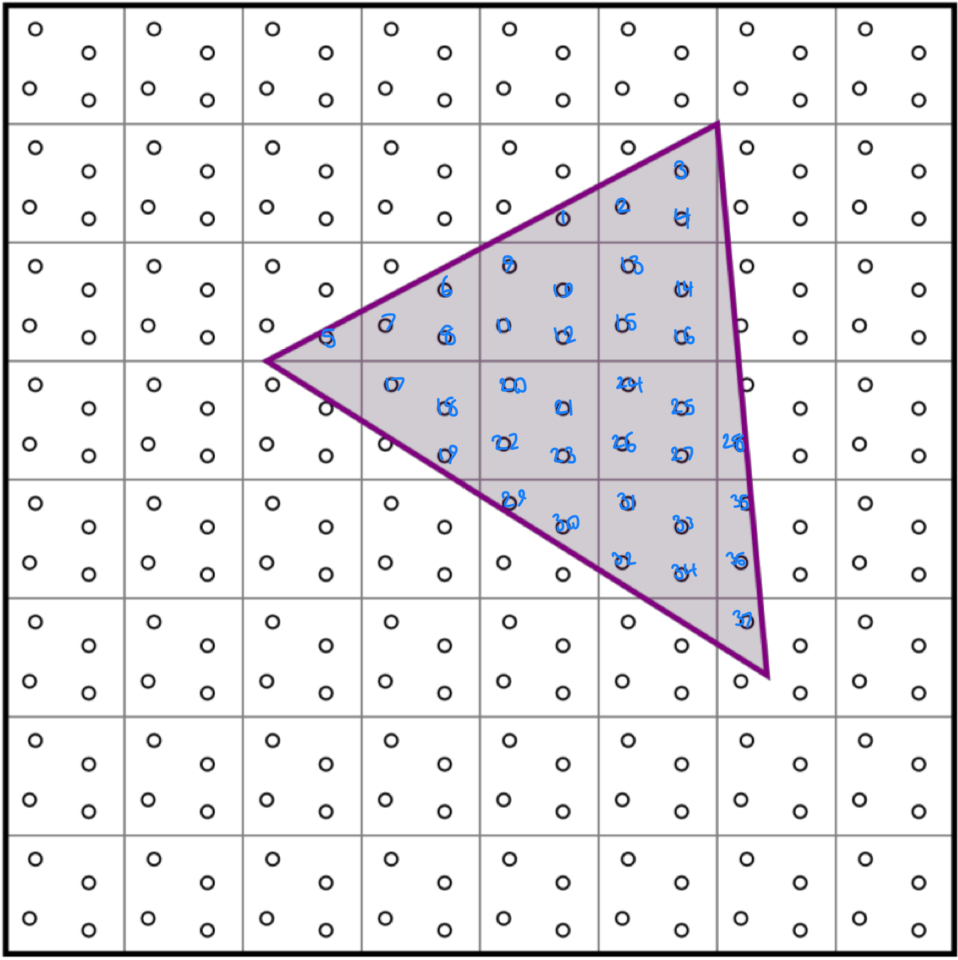

**Exercise 4.**
In this exercise you have to create an OpenGL program.
Please submit your source code along with your written solutions to the previous 3 exercises.
The following lists define two different sets of 11 vertices as 22 floats. They are ordered $v_{1x}$,$v_{1y}$,$v_{2x}$,$v_{2y}$,....
Your goal is to create an OpenGL program which continuously tweens between each. Your program should:
•
Define an orthographic viewing area bounded by $(-20,20)$ and $(20,20)$.
•
Over 400 frames, linearly tween from the star, to the decagon, and then back to the star. On each frame, draw the tweened vertices as a polyline.
•
Repeat this animation forever.
star $= \left[ {\begin{array}{cc}[0 &10 &2.5 &2.5 &10 &2.5 &4 &-2.5 &7 &-10 &0 &-5 &-7 &-10 &-4 &-2.5 &-10 &2.5 &-2.5 &2.5 &0 &10]\end{array} } \right]$
decagon $= \left[ {\begin{array}{cc}[5 &15.388 &13.0902 &9.51056 &16.1803 &0 &13.0902 &-9.51056 &5 &-15.388 &-5 &-15.388 &-13.0902 &-9.51056 &-16.1803 &0 &-13.0902 &9.51056 &-5 &15.388 &5 &15.388]\end{array} } \right]$

In [ ]:
import glfw
from OpenGL.GL import *
from OpenGL.GLUT import *
import numpy as np

# Updated star and decagon vertices
star = np.array([0, 10, 2.5, 2.5, 10, 2.5, 4, -2.5, 7, -10, 0, -5, -7, -10, -4, -2.5, -10, 2.5, -2.5, 2.5, 0, 10], dtype=np.float32)
decagon = np.array([5, 15.388, 13.0902, 9.51056, 16.1803, 0, 13.0902, -9.51056, 5, -15.388, -5, -15.388, -13.0902, -9.51056, -16.1803, 0, -13.0902, 9.51056, -5, 15.388, 5, 15.388], dtype=np.float32)

# Tween parameters
frames = 400  # Total number of frames for one tween
frame = 0     # Current frame index
tween_dir = 1 # Direction: 1 for star -> decagon, -1 for decagon -> star

# Linear interpolation function
def interpolate(v1, v2, t):
    return v1 + t * (v2 - v1)

# Initialize GLFW
if not glfw.init():
    raise Exception("GLFW could not be initialized.")

# Create a window
window = glfw.create_window(800, 800, "Star Tween Animation", None, None)
if not window:
    glfw.terminate()
    raise Exception("GLFW window could not be created.")

glfw.make_context_current(window)

# OpenGL initialization
glMatrixMode(GL_PROJECTION)
glLoadIdentity()
glOrtho(-20, 20, -20, 20, -1, 1)
glMatrixMode(GL_MODELVIEW)
glLoadIdentity()

# Display function
def draw():
    global frame, tween_dir

    # Clear the screen
    glClear(GL_COLOR_BUFFER_BIT)

    # Calculate interpolation factor
    t = frame / frames

    # Interpolate vertices
    if tween_dir == 1:
        vertices = interpolate(star, decagon, t)
    else:
        vertices = interpolate(decagon, star, t)

    # Draw the interpolated shape as a polyline
    glBegin(GL_LINE_LOOP)
    for i in range(0, len(vertices), 2):
        glVertex2f(vertices[i], vertices[i + 1])
    glEnd()

    # Swap buffers
    glfw.swap_buffers(window)

    # Increment frame counter
    frame += 1
    if frame > frames:
        frame = 0
        tween_dir *= -1  # Reverse tween direction

# Main loop
while not glfw.window_should_close(window):
    glfw.poll_events()
    draw()

# Cleanup
glfw.terminate()